# Numerical Solutions of Differential Equations in Python

# Example 1: Find Analytic and Numerical Solutions of ODE in Python

**Task 1.1: Find the analytic solution to the ODE**

ODE:
$$y' = 4x, \quad y(0) = 1, \quad x \in [0, 2.5]$$

Test Points:
* $ x_1=1.3125$, $x_2 = 0.5625$


Hint:
* `sp.Symbol('x')` defines a symbolic variable `x`
* `sp.Function('y')(x)` defines a function `y` with input `x`
* `sp.Eq(LHS, RHS)` defines an equation `LHS` $=$ `RHS`
* `sp.diff(y)` defines the derivative of the function `y`
* `sp.solve(eqn, y, ics={y.subs(x,x0): y0})` solve the ODE with initial condition $y(x_0) = y_0$

In [ ]:
# --------------------------------------------
# Step 1.1: Python code to find ANALYTIC SOLUTION of
# y' = 4x,  y(0) = 1,  x ∈ [0, 2.5]
# Uses symbolic math (SymPy) for exact solution
# --------------------------------------------
import sympy as sp
import numpy as np

# Step 1.1.1: Define symbolic variables
x = sp.Symbol('x')         # independent variable x
y = sp.Function('y')(x)    # dependent variable y(x)

# Step 1.1.2: Define the ODE: y' = 4x
ode = sp.Eq(sp.diff(y, x), 4*x)

# Step 1.1.3: Solve the ODE analytically with initial condition y(0) = 1
analytical_sol = sp.dsolve(ode, y, ics={y.subs(x, 0): 1})

# Steo 1.1.4: Print the EXACT analytical solution
print("===== Analytic Solution (Exact) =====")
print(analytical_sol)

# Step 1.1.5: Extract the right-hand side (formula for y(x))
y_exact = analytical_sol.rhs
print("\nExplicit formula: y(x) =", y_exact)

# --------------------------------------------
# Step 1.2: Evaluate the analytic solution at any x
# --------------------------------------------
# Step 1.2.1: Convert symbolic formula to a numerical function
y_func = sp.lambdify(x, y_exact, 'numpy')

# Step 1.2.2: Test at specific points (matches your problem)
x_test1 = 1.3125
x_test2 = 0.5625
y_test1 = y_func(x_test1)
y_test2 = y_func(x_test2)

print("\n===== Test Points =====")
print(f"At x = {x_test1}:  y = {y_test1}")
print(f"At x = {x_test2}:  y = {y_test2}")

# Step 1.2.3: Evaluate over the full interval [0, 2.5]
x_vals = np.linspace(0, 2.5, 10)
y_vals = y_func(x_vals)

print("\n===== Analytic Solution over x ∈ [0, 2.5] =====")
for xi, yi in zip(x_vals, y_vals):
    print(f"x = {xi:6.3f}    y = {yi:8.4f}")

===== Analytic Solution (Exact) =====
Eq(y(x), 2*x**2 + 1)

Explicit formula: y(x) = 2*x**2 + 1

===== Test Points =====
At x = 1.3125:  y = 4.4453125
At x = 0.5625:  y = 1.6328125

===== Analytic Solution over x ∈ [0, 2.5] =====
x =  0.000    y =   1.0000
x =  0.278    y =   1.1543
x =  0.556    y =   1.6173
x =  0.833    y =   2.3889
x =  1.111    y =   3.4691
x =  1.389    y =   4.8580
x =  1.667    y =   6.5556
x =  1.944    y =   8.5617
x =  2.222    y =  10.8765
x =  2.500    y =  13.5000


**Task 1.2: Find the numerical solution to the ODE**

ODE:
$$y' = 4x, \quad y(0) = 1, \quad x \in [0, 2.5]$$


Hint:
* ```
  solve_ivp(fun = f,
            t_span = interval,
            y0 = y0,
            method = 'RK45',
            t_eval = x_eval
  )
  ```
  solves the Initial Value Problem
  
$$
\frac{dy}{dt} = f(t,y), \quad y(t_0) = y_0
$$

  with function `f` in the interval `interval` with initial value `y0` using Explicit Runge-Kutta method of order 5(4) `RK45`

In [ ]:
# ---------------------------
# Step 1.3: Python Implementation: ODE Solving and Plotting
# Problem: y' = 4x, y(0) = 1, x ∈ [0, 2.5]
# ---------------------------
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ---------------------------
# Step 1.3.1. Define the ODE function
# ---------------------------
def ode_func(x, y):
    """Right-hand side of the ODE: dy/dx = 4x"""
    return 4 * x

# ---------------------------
# Step 1.3.2. Set problem parameters
# ---------------------------
x0 = 0                  # Initial x value
y0 = [1]                # Initial condition y(x0) = 1
xspan = [0, 2.5]        # Solution interval

# ---------------------------
# Step 1.3.3. Solve ODE with fixed evaluation points (stable, no index error)
# ---------------------------
x_eval = np.linspace(0, 2.5, 100)  # Define 100 stable points
sol = solve_ivp(
    fun=ode_func,
    t_span=xspan,
    y0=y0,
    method='RK45',
    t_eval=x_eval       # Use fixed points to guarantee enough data
)

# Extract solution results
xsol = sol.t
ysol = sol.y[0]

# ---------------------------
# Step 1.3.4. Analytical solution for comparison
# ---------------------------
def analytical_solution(x):
    """Analytical solution: y(x) = 2x² + 1"""
    return 2 * x**2 + 1

y_analytical = analytical_solution(xsol)

# ---------------------------
# Step 1.3.5. Print results safely (no index error)
# ---------------------------
print("=== Numerical Solution Points (First 10) ===")
print("x          y_numerical  y_analytical  error")
print("-" * 45)

# Use min to avoid index out of bounds
n_print = min(10, len(xsol))
for i in range(n_print):
    x = xsol[i]
    y_num = ysol[i]
    y_an = y_analytical[i]
    err = abs(y_num - y_an)
    print(f"{x:<10.6f} {y_num:<12.6f} {y_an:<12.6f} {err:.2e}")

# Step size info
print("\n=== Step Size Information ===")
dx = np.diff(xsol)
if len(dx) >= 5:
    print(f"First 5 step sizes: {dx[:5]}")
else:
    print(f"Step sizes: {dx}")
print(f"Average step size: {np.mean(dx):.6f}")

# Test points
print("\n=== Key Test Point Verification ===")
for x_test in [1.3125, 0.5625]:
    y_test = analytical_solution(x_test)
    print(f"x = {x_test:.6f}, Analytical y = {y_test:.6f}")

=== Numerical Solution Points (First 10) ===
x          y_numerical  y_analytical  error
---------------------------------------------
0.000000   1.000000     1.000000     0.00e+00
0.025253   1.001275     1.001275     2.22e-16
0.050505   1.005102     1.005102     2.22e-16
0.075758   1.011478     1.011478     0.00e+00
0.101010   1.020406     1.020406     2.22e-16
0.126263   1.031885     1.031885     0.00e+00
0.151515   1.045914     1.045914     0.00e+00
0.176768   1.062494     1.062494     0.00e+00
0.202020   1.081624     1.081624     0.00e+00
0.227273   1.103306     1.103306     0.00e+00

=== Step Size Information ===
First 5 step sizes: [0.02525253 0.02525253 0.02525253 0.02525253 0.02525253]
Average step size: 0.025253

=== Key Test Point Verification ===
x = 1.312500, Analytical y = 4.445312
x = 0.562500, Analytical y = 1.632812


**Task 1.3: Plot the results to compare the analytic solution and numerical solution**

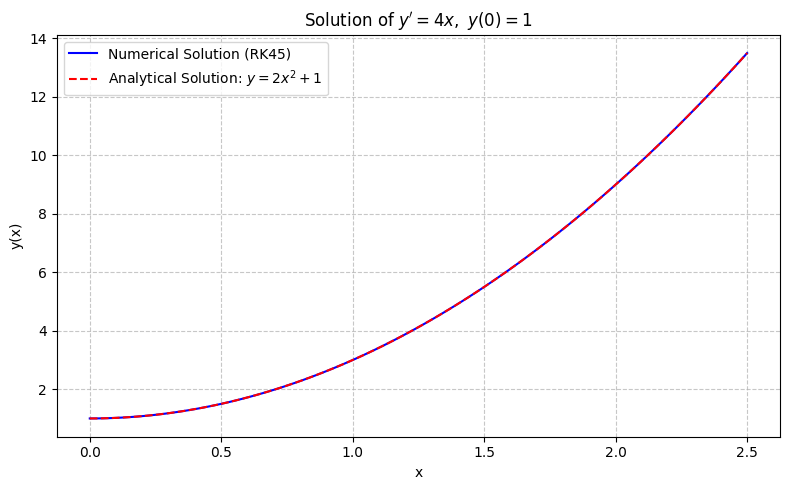

In [ ]:
# ---------------------------
# Step 1.3.6. Plot results
# ---------------------------
plt.figure(figsize=(8, 5))
plt.plot(xsol, ysol, 'b-', linewidth=1.5, label='Numerical Solution (RK45)')
plt.plot(xsol, y_analytical, 'r--', linewidth=1.5, label='Analytical Solution: $y=2x^2+1$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title(r'Solution of $y^\prime = 4x, \ y(0)=1$')
plt.legend()
plt.tight_layout()

# Example 2: Find Analytic and Numerical Solutions of ODE in Python

**Task 2.1: Find the analytic solution to the ODE**

ODE:
$$y' + 3y = x e^{2x}, \quad y(2) = -4, \quad x \in [2, 2.7].$$

Test Points:
* $ x_1=2$, $x_2 = 2.2$, $x_3 = 2.5$ and $x_4 = 2.7$


Hint:
* `sp.Symbol('x')` defines a symbolic variable `x`
* `sp.Function('y')(x)` defines a function `y` with input `x`
* `sp.Eq(LHS, RHS)` defines an equation `LHS` $=$ `RHS`
* `sp.diff(y)` defines the derivative of the function `y`
* `sp.solve(eqn, y, ics={y.subs(x,x0): y0})` solve the ODE with initial condition $y(x_0) = y_0$

In [ ]:
# ---------------------------
# Python Code: Analytical Solution for
# y' + 3y = x*exp(2x), y(2) = -4, x ∈ [2, 2.7]
# ---------------------------
import sympy as sp
import numpy as np

# Step 2.1: Define symbolic variables
x = sp.Symbol('x')
y = sp.Function('y')(x)

# Step 2.2: Define the ODE: y' + 3y = x*exp(2x)
ode = sp.Eq(sp.diff(y, x) + 3*y, x * sp.exp(2*x))

# Step 2.3: Solve the ODE with initial condition y(2) = -4
solution = sp.dsolve(ode, y, ics={y.subs(x, 2): -4})

# Step 2.4: Print the exact analytical solution
print("=== Exact Analytical Solution ===")
print(solution)

# Step 2.5: Step Extract the explicit formula for y(x)
y_exact = solution.rhs
print("\nExplicit formula:")
print(f"y(x) = {y_exact}")

# Step 2.6: Convert symbolic solution to a numerical function
y_func = sp.lambdify(x, y_exact, 'numpy')

# Step 2.7: Evaluate at key points
x_points = np.array([2, 2.2, 2.5, 2.7])
y_values = y_func(x_points)

print("\n=== Solution at key points ===")
for xi, yi in zip(x_points, y_values):
    print(f"x = {xi:.2f} → y = {yi:.4f}")

# Step 2.8: Optional: Evaluate over the full interval
x_interval = np.linspace(2, 2.7, 10)
y_interval = y_func(x_interval)

print("\n=== Solution over [2, 2.7] ===")
print("x\t\t y(x)")
print("---------------------------")
for xi, yi in zip(x_interval, y_interval):
    print(f"{xi:.2f}\t\t{yi:.4f}")

=== Exact Analytical Solution ===
Eq(y(x), x*exp(2*x)/5 - exp(2*x)/25 + (-9*exp(10)/25 - 4*exp(6))*exp(-3*x))

Explicit formula:
y(x) = x*exp(2*x)/5 - exp(2*x)/25 + (-9*exp(10)/25 - 4*exp(6))*exp(-3*x)

=== Solution at key points ===
x = 2.00 → y = -4.0000
x = 2.20 → y = 19.5980
x = 2.50 → y = 62.9918
x = 2.70 → y = 107.8065

=== Solution over [2, 2.7] ===
x		 y(x)
---------------------------
2.00		-4.0000
2.08		5.2233
2.16		14.3129
2.23		23.6600
2.31		33.6461
2.39		44.6591
2.47		57.1082
2.54		71.4389
2.62		88.1493
2.70		107.8065


**Task 2.2: Find the numerical solution to the ODE**

ODE:
$$y' + 3y = x e^{2x}, \quad y(2) = -4, \quad x \in [2, 2.7].$$

Test Points:
* $ x_1=2$, $x_2 = 2.2$, $x_3 = 2.5$ and $x_4 = 2.7$

Hint:
* ```
  solve_ivp(fun = f,
            t_span = interval,
            y0 = y0,
            method = 'RK45',
            t_eval = x_eval
  )
  ```
  solves the Initial Value Problem
  
$$
\frac{dy}{dt} = f(t,y), \quad y(t_0) = y_0
$$

  with function `f` in the interval `interval` with initial value `y0` using Explicit Runge-Kutta method of order 5(4) `RK45`

In [ ]:
# ---------------------------
# Python Implementation for Example 2
# Problem: y' + 3y = x*exp(2x), y(2) = -4, x ∈ [2, 2.7]
# ---------------------------
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import sympy as sp

# ---------------------------
# Step 2.2.1. Define the ODE Right-Hand Side
# ---------------------------
def ode_func(x, y):
    """
    Right-hand side of the ODE, rearranged for numerical solving:
    y' = -3y + x*exp(2x)
    """
    return -3 * y + x * np.exp(2 * x)

# ---------------------------
# Step 2.2.2. Set Problem Parameters
# ---------------------------
x0 = 2                  # Initial x value
y0 = [-4]               # Initial condition y(2) = -4
xspan = [2, 2.7]        # Solution interval

# ---------------------------
# Step 2.2.3. Solve ODE Numerically (RK45)
# ---------------------------
# Use fixed points to guarantee stable output
x_eval = np.linspace(2, 2.7, 100)
sol = solve_ivp(
    fun=ode_func,
    t_span=xspan,
    y0=y0,
    method='RK45',
    t_eval=x_eval
)

# Safe extraction of results
xsol = sol.t
ysol = sol.y[0] if sol.y.ndim > 1 else sol.y

# ---------------------------
# Step 2.2.4. Analytical Solution (SymPy)
# ---------------------------
x_sym = sp.Symbol('x')
y_sym = sp.Function('y')(x_sym)
ode_sym = sp.Eq(sp.diff(y_sym, x_sym) + 3 * y_sym, x_sym * sp.exp(2 * x_sym))
solution_sym = sp.dsolve(ode_sym, y_sym, ics={y_sym.subs(x_sym, 2): -4})

# Convert symbolic solution to a numerical function
y_analytical_func = sp.lambdify(x_sym, solution_sym.rhs, 'numpy')
y_analytical = y_analytical_func(xsol)


# ---------------------------
# Step 2.2.5. Safe Verification (FIXED: NO INDEX ERROR)
# ---------------------------
print("=== Exact Analytical Solution ===")
print(solution_sym)

print("\n=== Verification at Key Points ===")
test_points = [2.0, 2.2, 2.5, 2.7]

# Use precomputed solution for safety (NO SOLVE INSIDE LOOP)
for x_test in test_points:
    # Get analytical value
    y_an = y_analytical_func(x_test)

    # Interpolate numerical solution (safe, no index risk)
    y_num = np.interp(x_test, xsol, ysol)

    print(f"x = {x_test:.2f}: Numerical y = {y_num:.4f}, Analytical y = {y_an:.4f}")

=== Exact Analytical Solution ===
Eq(y(x), x*exp(2*x)/5 - exp(2*x)/25 + (-9*exp(10)/25 - 4*exp(6))*exp(-3*x))

=== Verification at Key Points ===
x = 2.00: Numerical y = -4.0000, Analytical y = -4.0000
x = 2.20: Numerical y = 19.5986, Analytical y = 19.5980
x = 2.50: Numerical y = 62.9424, Analytical y = 62.9918
x = 2.70: Numerical y = 107.8438, Analytical y = 107.8065


**Task 2.3: Plot the results to compare the analytic solution and numerical solution**

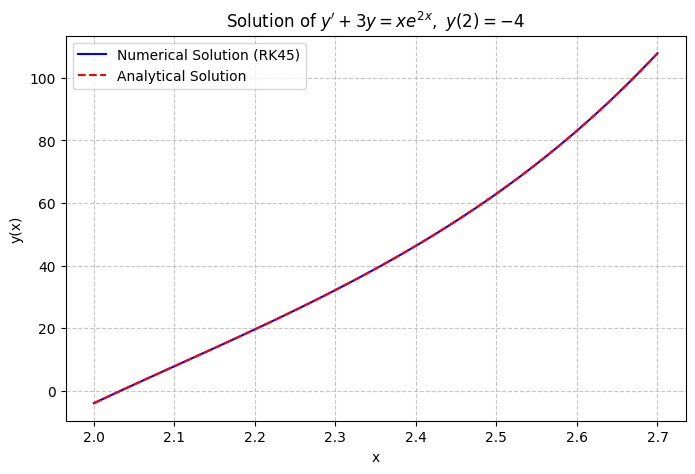

In [ ]:
# ---------------------------
# Step 2.2.6. Plot Solutions
# ---------------------------
plt.figure(figsize=(8, 5))
plt.plot(xsol, ysol, 'b-', linewidth=1.5, label='Numerical Solution (RK45)')
plt.plot(xsol, y_analytical, 'r--', linewidth=1.5, label='Analytical Solution')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title(r'Solution of $y^\prime + 3y = x e^{2x}, \ y(2)=-4$')
plt.legend();

# Example 3: System of First-Order ODEs

**Task 3.1: Find the analytic solution to the ODE**

ODE:
$$
\begin{cases}
\dfrac{dx}{dt} = y^2 - x \\[6pt]
\dfrac{dy}{dt} = 0.5x^2 - y
\end{cases}
\quad
\begin{bmatrix} x(0) \\ y(0) \end{bmatrix}
=
\begin{bmatrix} 1 \\ 0 \end{bmatrix},
\quad t \in [0, 3].
$$

Hint:
* ```
  solve_ivp(fun = f,
            t_span = interval,
            y0 = y0,
            method = 'RK45',
            t_eval = x_eval
  )
  ```
  solves the Initial Value Problem
  
$$
\frac{dy}{dt} = f(t,y), \quad y(t_0) = y_0
$$

In [ ]:
# ---------------------------
# Python Implementation for Example 2.7
# System of ODEs:
# dx/dt = y^2 - x
# dy/dt = 0.5*x^2 - y
# Initial conditions: x(0)=1, y(0)=0, t ∈ [0, 3]
# ---------------------------
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ---------------------------
# Step 3.3.1. Define the ODE System
# ---------------------------
def ode_system(t, state):
    """
    Defines the system of first-order ODEs.
    Input:
        t: independent variable (time)
        state: list [x, y] containing the current values of the state variables
    Output:
        dstate_dt: list [dx/dt, dy/dt] containing the derivatives
    """
    x, y = state
    dxdt = y**2 - x
    dydt = 0.5 * x**2 - y
    return [dxdt, dydt]

# ---------------------------
# Step 3.3.2. Set Problem Parameters
# ---------------------------
t0 = 0                  # Initial time
u0 = [1, 0]             # Initial state [x(0), y(0)]
tspan = [t0, 3]         # Time interval [0, 3]

# ---------------------------
# Step 3.3.3. Solve the System Numerically (RK45, equivalent to MATLAB ode45)
# ---------------------------
# Define fixed evaluation points for stable plotting
t_eval = np.linspace(0, 3, 100)
sol = solve_ivp(
    fun=ode_system,
    t_span=tspan,
    y0=u0,
    method='RK45',      # Adaptive Runge-Kutta method (matches MATLAB ode45)
    t_eval=t_eval       # Use fixed points for guaranteed output
)

# Extract results
tsol = sol.t            # Time points
xsol = sol.y[0]         # Solution x(t)
ysol = sol.y[1]         # Solution y(t)

# ---------------------------
# Step 3.3.4. Print Verification Information
# ---------------------------
print("=== System ODE Solution (RK45) ===")
print("Initial conditions: x(0)=1, y(0)=0")
print("Time interval: [0, 3]")

print("\n=== Values at Key Time Points ===")
test_times = [0, 1, 2, 3]
for t in test_times:
    # Interpolate to get values at the test time
    x_val = np.interp(t, tsol, xsol)
    y_val = np.interp(t, tsol, ysol)
    print(f"t = {t:.1f}: x(t) = {x_val:.4f}, y(t) = {y_val:.4f}")

=== System ODE Solution (RK45) ===
Initial conditions: x(0)=1, y(0)=0
Time interval: [0, 3]

=== Values at Key Time Points ===
t = 0.0: x(t) = 1.0000, y(t) = 0.0000
t = 1.0: x(t) = 0.3756, y(t) = 0.1175
t = 2.0: x(t) = 0.1428, y(t) = 0.0601
t = 3.0: x(t) = 0.0535, y(t) = 0.0245


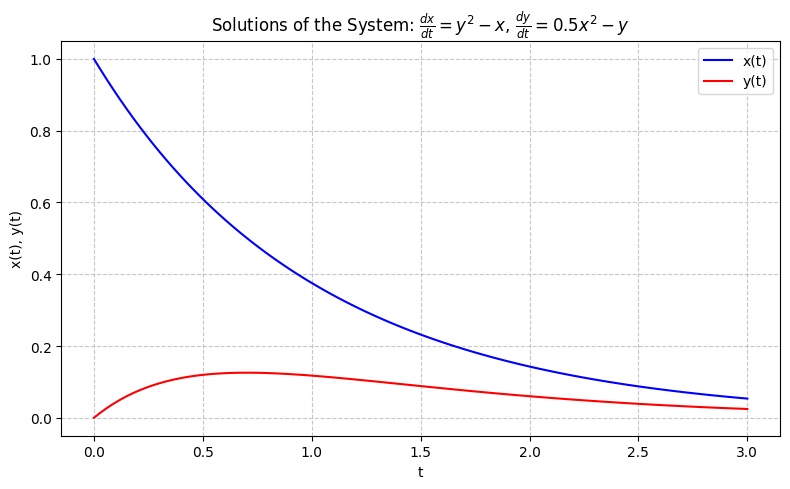

In [ ]:
# ---------------------------
# Step 3.3.5. Plot the Solutions
# ---------------------------
plt.figure(figsize=(8, 5))
plt.plot(tsol, xsol, 'b-', linewidth=1.5, label='x(t)')
plt.plot(tsol, ysol, 'r-', linewidth=1.5, label='y(t)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('t')
plt.ylabel('x(t), y(t)')
plt.title(r'Solutions of the System: $\frac{dx}{dt}=y^2-x$, $\frac{dy}{dt}=0.5x^2-y$')
plt.legend()
plt.tight_layout()